In [307]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

In [257]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [343]:
ticker = 'MSFT'
start_date = '2020-01-01'
end_date = '2026-04-29'

In [344]:
df = yf.download(ticker, start=start_date, end=end_date)

[*********************100%***********************]  1 of 1 completed


<Axes: xlabel='Date'>

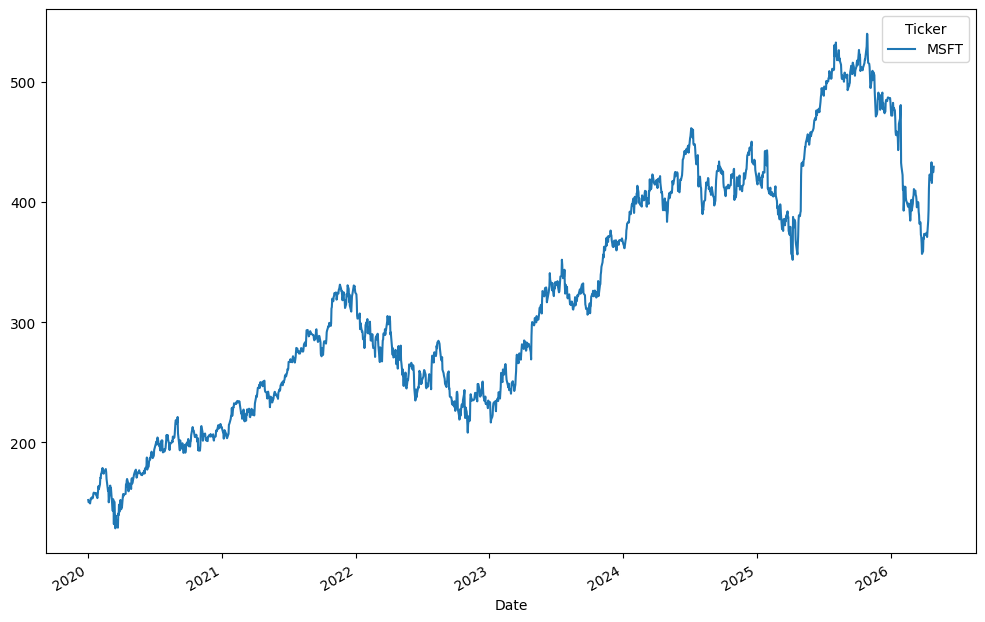

In [345]:
df.Close.plot(figsize=(12,8))

In [382]:
from sklearn.preprocessing import MinMaxScaler


scaler = MinMaxScaler(feature_range=(0, 1))
df['Close'] = scaler.fit_transform(df[['Close']])

In [396]:
lookback = 30
data = []

for i in range(len(df) - lookback):
    data.append(df['Close'][i:i+lookback])

data = np.array(data)


In [397]:
df

Price,Close,High,Low,Open,Volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT
Date,,,,,
2020-01-02,0.057205,152.262577,149.989017,150.415308,22622100
2020-01-03,0.052597,151.523654,149.733221,149.979534,21116200
2020-01-06,0.053542,150.718465,148.264897,148.804876,20813700
2020-01-07,0.050201,151.258458,149.032267,150.926905,21634100
2020-01-08,0.055984,152.328883,149.629019,150.557387,27746500
...,...,...,...,...,...
2026-04-22,0.740009,433.700012,423.670013,426.190002,29378200
2026-04-23,0.698252,423.660004,411.410004,419.890015,38308000


In [395]:
df['Close']

Ticker,MSFT
Date,
2020-01-02,0.057205
2020-01-03,0.052597
2020-01-06,0.053542
2020-01-07,0.050201
2020-01-08,0.055984
...,...
2026-04-22,0.740009
2026-04-23,0.698252
2026-04-24,0.719824


In [384]:
train_size = int(0.8*len(data))

x_train = torch.from_numpy(data[:train_size, :-1, :]).type(torch.Tensor).to(device)
y_train = torch.from_numpy(data[:train_size, -1, :]).type(torch.Tensor).to(device)

x_test = torch.from_numpy(data[train_size:, :-1, :]).type(torch.Tensor).to(device)
y_test = torch.from_numpy(data[train_size:, -1, :]).type(torch.Tensor).to(device)

In [385]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=2, output_size=1, dropout=0.2):
        super(LSTMModel, self).__init__()
        
        self.num_layerss = num_layers
        self.hidden_size = hidden_size

        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layerss, x.size(0), self.hidden_size, device=device)
        c0 = torch.zeros(self.num_layerss, x.size(0), self.hidden_size, device=device)

        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))
        out = self.fc(out[:, -1, :])

        return out

In [386]:
model = LSTMModel().to(device)

In [387]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [388]:
epochs = 100

for epoch in range(epochs):
    y_train_pred = model(x_train)

    loss = criterion(y_train_pred, y_train)

    if epoch%10 == 0:
        print(epoch, loss.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

0 0.14909835159778595
10 0.03542891889810562
20 0.0164744071662426
30 0.004285053815692663
40 0.0016732870135456324
50 0.001083576469682157
60 0.0008124024025164545
70 0.0007204308058135211
80 0.0006783328135497868
90 0.0006296538049355149


In [389]:
model.eval()

y_test_pred = model(x_test)

In [390]:
y_train_pred = scaler.inverse_transform(y_train_pred.detach().cpu().numpy())
y_train = scaler.inverse_transform(y_train.detach().cpu().numpy())
y_test_pred = scaler.inverse_transform(y_test_pred.detach().cpu().numpy())
y_test = scaler.inverse_transform(y_test.detach().cpu().numpy())

In [391]:
y_train

array([[0.11040094],
       [0.11417942],
       [0.11851051],
       ...,
       [0.7567521 ],
       [0.73386985],
       [0.76431537]], shape=(1246, 1), dtype=float32)

In [392]:
train_rmse = root_mean_squared_error(y_train, y_train_pred)
test_rmse = root_mean_squared_error(y_test, y_test_pred)

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

train_mape = mean_absolute_percentage_error(y_train, y_train_pred)
test_mape = mean_absolute_percentage_error(y_test, y_test_pred)

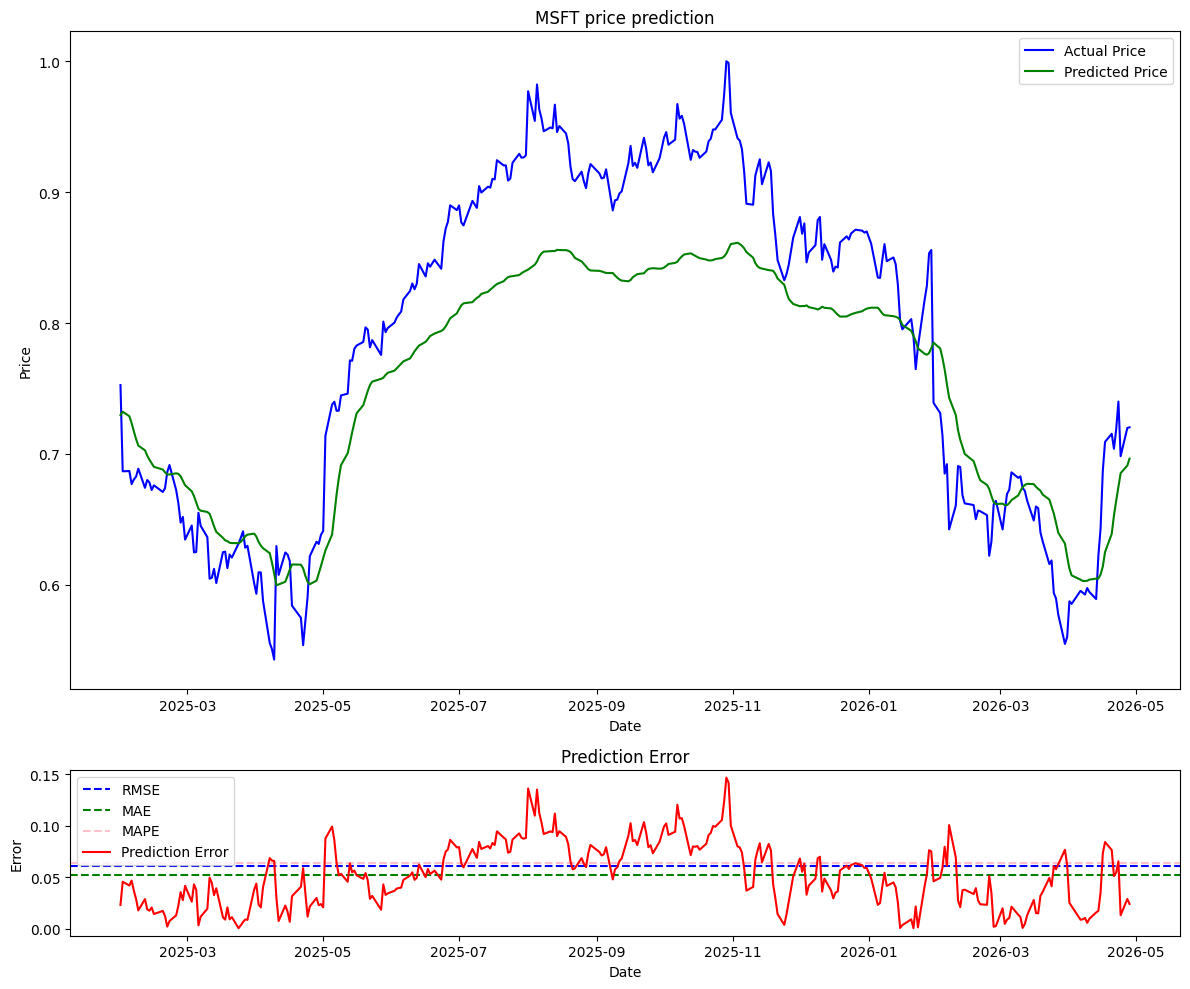

In [393]:
fig = plt.figure(figsize=(12,10))
gs = fig.add_gridspec(4,1)
ax1 = fig.add_subplot(gs[:3, 0])
ax1.plot(df.iloc[-len(y_test):].index, y_test, color='blue', label='Actual Price')
ax1.plot(df.iloc[-len(y_test):].index, y_test_pred, color='green', label='Predicted Price')
ax1.legend()
plt.title(f"{ticker} price prediction")
plt.xlabel('Date')
plt.ylabel('Price')

ax2 = fig.add_subplot(gs[3,0])
ax2.axhline(test_rmse, color='blue', linestyle='--', label='RMSE')
ax2.axhline(test_mae, color='green', linestyle='--', label='MAE')
ax2.axhline(test_mape, color='pink', linestyle='--', label='MAPE')
ax2.plot(df[-len(y_test):].index, abs(y_test - y_test_pred), 'r', label = 'Prediction Error')
ax2.legend()
plt.title('Prediction Error')
plt.xlabel('Date')
plt.ylabel('Error')
plt.tight_layout()

plt.show()